###train_fe_kisu.csv 기준으로 모델을 학습

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split



In [2]:
train = pd.read_csv('../data/fe/train_fe_kisu_v2.csv')
test  = pd.read_csv('../data/fe/test_fe_kisu_v2.csv')


FileNotFoundError: [Errno 2] No such file or directory: '../data/fe/train_fe_kisu_v2.csv'

In [ ]:
cat_features = X.select_dtypes(include='object').columns.tolist()
print(cat_features)


['gender', 'car', 'reality', 'income_type', 'edu_type', 'family_type', 'house_type', 'occyp_type']


C:\Users\ghkdr\AppData\Local\Temp\ipykernel_35760\1550951072.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include='object').columns.tolist()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    random_seed=42,
    verbose=200
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)


0:	learn: 1.0812638	test: 1.0812342	best: 1.0812342 (0)	total: 39.3ms	remaining: 39.3s
200:	learn: 0.7974745	test: 0.8031185	best: 0.8031183 (199)	total: 8s	remaining: 31.8s
400:	learn: 0.7818045	test: 0.7977639	best: 0.7977639 (400)	total: 16.2s	remaining: 24.2s
600:	learn: 0.7620110	test: 0.7914375	best: 0.7914288 (599)	total: 24.8s	remaining: 16.4s
800:	learn: 0.7459807	test: 0.7872482	best: 0.7872482 (800)	total: 33.3s	remaining: 8.26s
999:	learn: 0.7321172	test: 0.7844447	best: 0.7844447 (999)	total: 41.8s	remaining: 0us

bestTest = 0.7844446632
bestIteration = 999



In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_valid)

print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

         0.0       0.67      0.01      0.01       644
         1.0       0.72      0.25      0.37      1254
         2.0       0.69      0.99      0.82      3394

    accuracy                           0.70      5292
   macro avg       0.69      0.41      0.40      5292
weighted avg       0.70      0.70      0.61      5292



In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

feature_importance.head(15)


,feature,importance
19,card_duration,16.121069
15,begin_month,13.885567
16,age,9.895088
13,occyp_type,7.764520
4,income_total,7.558253
18,income_per_person,6.766447
17,employment_years,6.089679
7,family_type,5.714250
5,income_type,5.085770
6,edu_type,4.961370


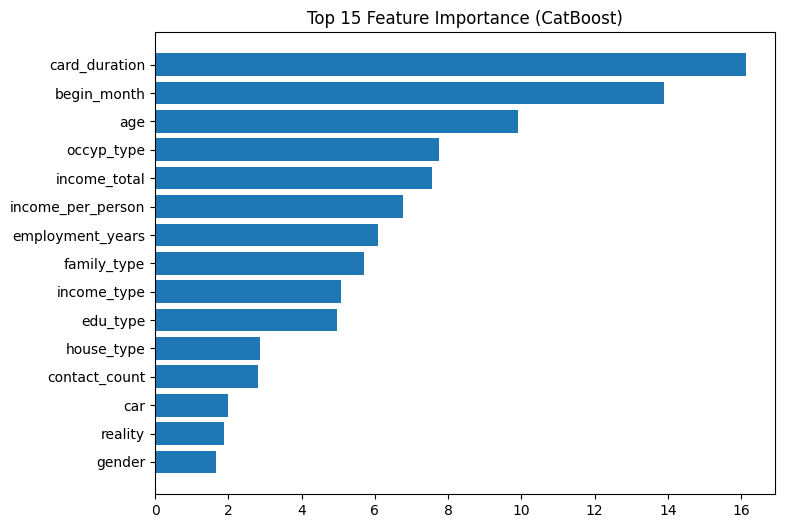

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(
    feature_importance['feature'][:15][::-1],
    feature_importance['importance'][:15][::-1]
)
plt.title('Top 15 Feature Importance (CatBoost)')
plt.show()


In [ ]:
# ===============================
# Submission file generation (safe)
# ===============================
import pandas as pd
import numpy as np

# 1) 예측 확률
test_pred = model.predict_proba(test)

# 2) sample_submission 로드
submission = pd.read_csv('../data/sample_submission.csv')

# 3) 확률 컬럼 (맨 앞 index 제외)
proba_cols = submission.columns[1:]

# 4) dtype float 강제 (LossySetitemError 방지)
submission[proba_cols] = submission[proba_cols].astype(float)

# 5) shape 검증 (제출 형식 불일치 방지)
assert test_pred.shape[1] == len(proba_cols), f"test_pred cols={test_pred.shape[1]}, submission cols={len(proba_cols)}"
assert len(submission) == len(test), f"submission rows={len(submission)}, test rows={len(test)}"

# 6) 대입
submission.loc[:, proba_cols] = test_pred

# 7) 저장
submission.to_csv('../data/csv/submission_kisu_v1.csv', index=False)
print("Saved: ../data/csv/submission_kisu_v1.csv")

# 8) 확인
display(submission.head())
print(submission.dtypes)
print(submission.isna().sum())


Saved: ../data/csv/submission_kisu_v1.csv


,index,0,1,2
0,26457,0.103531,0.187590,0.708879
1,26458,0.135960,0.145681,0.718358
2,26459,0.139766,0.206830,0.653404
3,26460,0.116761,0.154428,0.728810
4,26461,0.118572,0.174817,0.706611


index      int64
0        float64
1        float64
2        float64
dtype: object
index    0
0        0
1        0
2        0
dtype: int64
